# Resumen — Aprendizaje No Supervisado (Clustering, K-Means, PCA)

> **Cuaderno explicativo del `TP_Unidad6_Aprendizaje_No_Supervisado.ipynb`**
> Acompaña, paso a paso, cada parte del práctico: qué se hizo, por qué se hizo así, y qué teoría hay detrás. Está pensado para leerlo *después* de haber intentado el TP por tu cuenta, no en lugar de intentarlo.

Este resumen sigue la misma estructura de 7 partes que el TP original. Cada sección tiene: **teoría** (de las diapositivas de la Unidad 6) → **código** (el mismo que resolvimos en el TP) → **interpretación** de lo que salió.


---
## Parte 0 — Antes de arrancar: ¿qué es "no supervisado"?

Hasta ahora (regresión lineal, logística, KNN, árboles, bosques) siempre había una columna `y` con la respuesta correcta, y el modelo aprendía a predecirla. Eso es **aprendizaje supervisado**.

En este TP **no hay ningún `y`**. Solo tenemos filas de datos (clientes, usuarios) y le pedimos al algoritmo que **encuentre grupos por su cuenta**, sin decirle de antemano cuáles son ni cuántos hay "en teoría". A eso se le llama **aprendizaje no supervisado**.

| Característica | Supervisado | No Supervisado |
|---|---|---|
| Etiquetas (y) | Sí, disponibles | No existen |
| Objetivo | Predecir una variable target | Descubrir estructura oculta |
| Algoritmos típicos | Regresión Lineal, Random Forest | K-Means, DBSCAN, PCA |
| Cómo se evalúa | Accuracy, MAE, F1, RMSE (comparando contra la respuesta real) | Silhouette, Inercia (no hay "respuesta real" contra qué comparar) |
| Casos de uso | Precio de una casa, diagnóstico médico | Segmentación de clientes, detección de anomalías |

**La pregunta clave que responde el Ejercicio 1.1 del TP:** ¿por qué es más difícil saber si un modelo no supervisado "funcionó bien"?

Porque en supervisado tenés una respuesta correcta objetiva para comparar (¿acertó o no?). En no supervisado, **no existe un "grupo correcto" preestablecido** — el propio algoritmo inventa la agrupación. Por eso usamos métricas *internas* (silhouette, inercia) que miden qué tan compactos y separados quedaron los grupos, en lugar de comparar contra una verdad conocida. Y por eso, al final, siempre hace falta el juicio humano para decidir si esos grupos tienen sentido de negocio.

Dos casos reales donde no se puede usar supervisado porque no existen etiquetas históricas confiables:
- **Segmentación de clientes nuevos de una empresa**: nadie etiquetó de antemano "este cliente es tipo A, este es tipo B" — ese tipo es justamente lo que queremos descubrir.
- **Detección de fraude o anomalías en transacciones**: los casos de fraude son tan raros y cambiantes que no hay suficientes ejemplos etiquetados como para entrenar un clasificador confiable; en cambio, se buscan puntos que "no se parecen a nada conocido".


---
## Parte 1 — Imports

Igual que en los TPs de árboles y bosques, arrancamos importando todo lo que vamos a usar. Lo nuevo acá (respecto a los TPs de clasificación) son tres imports puntuales:

- `StandardScaler` (de `sklearn.preprocessing`): para escalar los datos — clave en clustering, lo explicamos en la Parte 3.
- `KMeans` (de `sklearn.cluster`): el algoritmo de clustering que vamos a usar.
- `PCA` (de `sklearn.decomposition`): para poder *visualizar* clusters de más de 2-3 variables en un gráfico 2D.
- `silhouette_score` (de `sklearn.metrics`): la métrica interna para evaluar qué tan buenos son los clusters.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

---
## Parte 2 — El dataset de clientes

El TP genera un dataset **simulado** (no viene de un CSV real) para que sepamos de antemano "la verdad" y podamos chequear si K-Means la encuentra sola. Se crean 3 grupos de clientes con perfiles bien distintos (jóvenes de bajo gasto, adultos premium, mayores leales) y después se mezclan en un único DataFrame, como si no supiéramos a qué grupo pertenece cada fila.

Variables: `edad`, `ingreso_anual` (miles de $), `gasto_mensual` ($), `frecuencia_compras` (compras/año), `antiguedad_meses`.


In [2]:
np.random.seed(42)
n = 300

grupo_1 = pd.DataFrame({
    'edad': np.random.normal(25, 4, 100).astype(int),
    'ingreso_anual': np.random.normal(30, 5, 100),
    'gasto_mensual': np.random.normal(80, 15, 100),
    'frecuencia_compras': np.random.normal(5, 2, 100).astype(int),
    'antiguedad_meses': np.random.normal(12, 4, 100).astype(int)
})
grupo_2 = pd.DataFrame({
    'edad': np.random.normal(40, 5, 100).astype(int),
    'ingreso_anual': np.random.normal(70, 10, 100),
    'gasto_mensual': np.random.normal(250, 40, 100),
    'frecuencia_compras': np.random.normal(15, 3, 100).astype(int),
    'antiguedad_meses': np.random.normal(36, 8, 100).astype(int)
})
grupo_3 = pd.DataFrame({
    'edad': np.random.normal(55, 6, 100).astype(int),
    'ingreso_anual': np.random.normal(55, 8, 100),
    'gasto_mensual': np.random.normal(150, 25, 100),
    'frecuencia_compras': np.random.normal(8, 2, 100).astype(int),
    'antiguedad_meses': np.random.normal(60, 12, 100).astype(int)
})

df = pd.concat([grupo_1, grupo_2, grupo_3], ignore_index=True)
df = df.clip(lower=0)

print(f'Shape del dataset: {df.shape}')
df.describe().T.round(2)

Shape del dataset: (300, 5)


,count,mean,std,min,25%,50%,75%,max
edad,300.0,39.50,13.67,14.00,26.00,38.50,52.00,67.00
ingreso_anual,300.0,52.07,18.65,20.41,32.56,54.91,66.59,95.73
gasto_mensual,300.0,160.62,74.88,31.38,91.11,151.06,221.18,355.30
frecuencia_compras,300.0,9.11,4.97,0.00,5.00,8.00,13.00,22.00
antiguedad_meses,300.0,36.55,22.74,2.00,14.00,36.00,53.25,91.00


**Lo que hay que mirar en el `describe()`:** fijate el `min` y `max` de cada columna. `ingreso_anual` se mueve entre ~20 y ~95, pero `frecuencia_compras` se mueve entre 0 y ~22. Esa diferencia de escala es exactamente el problema que vamos a resolver en la Parte 3 — anotalo, porque va a explicar por qué hace falta escalar.

También verificamos que no haya valores nulos (acá no los hay porque el dataset es simulado, pero en un caso real siempre hay que chequearlo antes de escalar — un `NaN` rompe `StandardScaler`).

In [3]:
df.isnull().sum()

edad                  0
ingreso_anual         0
gasto_mensual         0
frecuencia_compras    0
antiguedad_meses      0
dtype: int64

---
## Parte 3 — Escalado: por qué es *obligatorio* antes de K-Means

### La razón matemática

K-Means agrupa puntos según su **distancia euclidiana** — la misma fórmula de "distancia entre dos puntos" que se usa en KNN. El problema es que esa distancia se calcula sumando las diferencias al cuadrado de *todas* las variables:

$$d = \sqrt{(x_1-y_1)^2 + (x_2-y_2)^2 + \dots}$$

Si `ingreso_anual` varía en un rango de 20 a 95 (una diferencia de hasta 75) y `frecuencia_compras` varía de 0 a 22 (una diferencia de hasta 22), el término de `ingreso_anual` va a dominar la suma casi por completo. En la práctica, K-Means terminaría agrupando **casi exclusivamente por ingreso**, ignorando las demás variables — no porque el ingreso sea más importante, sino porque tiene números más grandes.

### La solución: `StandardScaler`

Transforma cada columna para que tenga **media 0 y desvío estándar 1**:

$$z = \frac{x - \text{media}}{\text{desvío estándar}}$$

Después de esto, todas las variables "pesan" lo mismo en el cálculo de distancia, sin importar en qué unidades venían originalmente.

> **Nota importante:** a diferencia del aprendizaje supervisado, acá *no* separamos en train/test — no hay `y`, así que el scaler se ajusta (`fit`) sobre **todo** el dataset.


In [4]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
X_scaled.describe().round(2)

,edad,ingreso_anual,gasto_mensual,frecuencia_compras,antiguedad_meses
count,300.00,300.00,300.00,300.00,300.00
mean,-0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.87,-1.70,-1.73,-1.83,-1.52
25%,-0.99,-1.05,-0.93,-0.83,-0.99
50%,-0.07,0.15,-0.13,-0.22,-0.02
75%,0.92,0.78,0.81,0.78,0.74
max,2.02,2.35,2.60,2.60,2.40


Fijate en la fila `mean` (≈0.00 en todas las columnas) y `std` (≈1.00 en todas) — es la firma de que el escalado funcionó. Ahora todas las variables están en la misma escala relativa, sin importar que originalmente `gasto_mensual` llegara a 350 y `frecuencia_compras` solo a 22.

**Un detalle de implementación que vale la pena marcar:** convertimos el resultado de `scaler.fit_transform(df)` (que por defecto es un array de NumPy "pelado", sin nombres de columna) de vuelta a un `DataFrame` con `pd.DataFrame(..., columns=df.columns)`. Esto no es puramente estético: más adelante necesitamos poder hacerle `.drop('cluster', axis=1)` por nombre de columna, y graficarlo con `sns.boxplot` mostrando los nombres de las variables en el eje X. Si te quedás con el array de NumPy plano, esas dos cosas se complican.

Podemos comparar visualmente el antes/después con un boxplot:

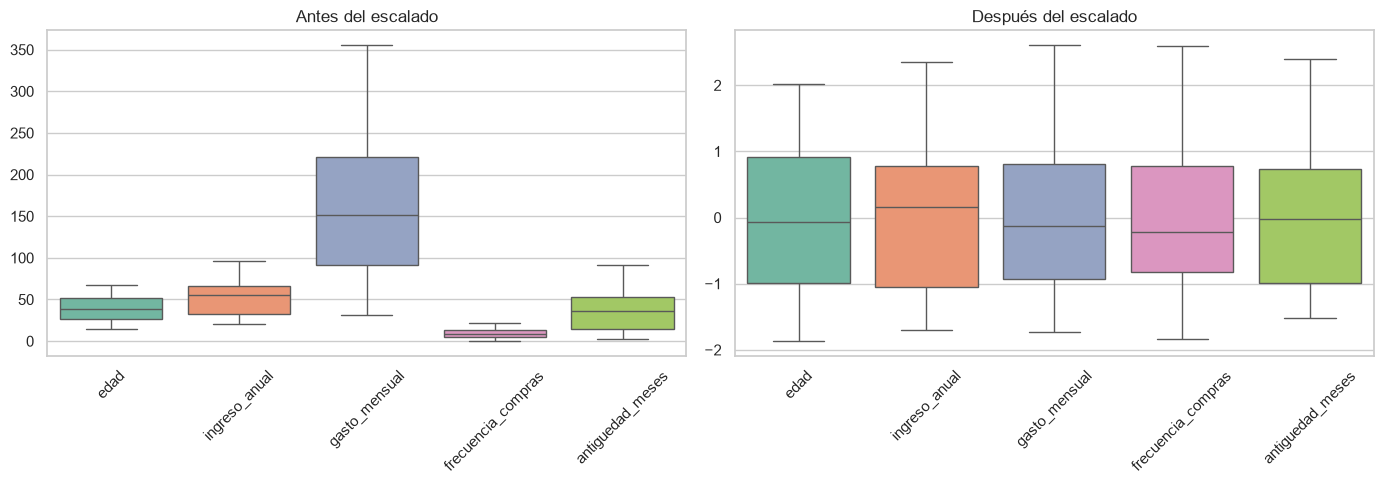

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, ax=axes[0])
axes[0].set_title('Antes del escalado')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=X_scaled, ax=axes[1])
axes[1].set_title('Después del escalado')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

En el panel izquierdo, `gasto_mensual` tiene una caja enorme comparada con `frecuencia_compras`, que casi ni se ve — esa es la distorsión de escala. En el panel derecho, todas las cajas ocupan un rango parecido alrededor de 0: ese es el efecto de `StandardScaler`.

---
## Parte 4 — El algoritmo K-Means

### Cómo funciona, paso a paso

1. **Inicializar centroides**: se eligen K puntos (al azar, o con `k-means++`, una inicialización más inteligente) como centros iniciales de los clusters.
2. **Asignar puntos**: cada punto del dataset se asigna al centroide más cercano (distancia euclidiana).
3. **Recalcular centroides**: el centroide de cada cluster pasa a ser el **promedio** de todos los puntos que le fueron asignados.
4. **Iterar**: se repiten los pasos 2 y 3 hasta que los centroides dejan de moverse significativamente (convergencia).

### La métrica que minimiza: inercia (WCSS)

**Inercia** (*Within-Cluster Sum of Squares*): la suma de las distancias al cuadrado de cada punto a su propio centroide. K-Means busca la asignación de clusters que la haga lo más chica posible — cuanto menor la inercia, más "compactos" (apretados alrededor de su centro) quedan los clusters.

### El código

`n_init=10` significa que K-Means se corre 10 veces completas con distintas inicializaciones aleatorias, y sklearn se queda con la mejor (la de menor inercia) — esto es porque el resultado final puede depender de dónde arrancaron los centroides, y así se reduce esa dependencia del azar.


In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10, init='k-means++')
kmeans.fit(X_scaled)

df['cluster'] = kmeans.labels_
X_scaled['cluster'] = kmeans.labels_

print(f'Inercia (WCSS) con K=3: {kmeans.inertia_:.2f}')

Inercia (WCSS) con K=3: 244.55


Guardamos las etiquetas de cluster (`kmeans.labels_`, un array con un número de 0 a K-1 por cada fila) **tanto en `df` como en `X_scaled`**. ¿Por qué en los dos? Porque más adelante:
- Usamos `df` (valores originales, sin escalar) para calcular el perfil promedio de cada cluster — así los números son interpretables (edad real, ingreso real en miles de $, etc.), no z-scores.
- Usamos `X_scaled` para el Elbow Method y el PCA, porque esos cálculos tienen que hacerse siempre sobre los datos escalados (es la misma razón de la Parte 3: si no, vuelven a dominar las variables de mayor escala).

### Perfil de cada cluster

Con `groupby('cluster').mean()` calculamos el promedio de cada variable dentro de cada grupo — así "leemos" qué tipo de cliente representa cada cluster.

In [7]:
perfil_clusters = df.groupby('cluster').mean().round(2)
perfil_clusters

,edad,ingreso_anual,gasto_mensual,frecuencia_compras,antiguedad_meses
cluster,,,,,
0,55.66,55.68,151.13,7.44,62.86
1,24.14,30.11,80.97,4.69,11.27
2,38.86,70.27,248.78,15.11,35.79


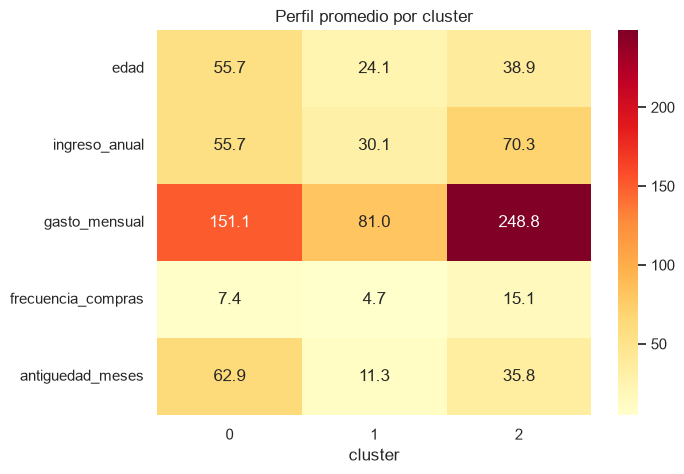

In [8]:
plt.figure(figsize=(7, 5))
sns.heatmap(perfil_clusters.T, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Perfil promedio por cluster')
plt.show()

**Interpretación de los 3 clusters** (con los números reales que salieron al correr este cuaderno):

| Cluster | edad | ingreso | gasto | frecuencia | antigüedad | Interpretación |
|---|---|---|---|---|---|---|
| 0 | ~56 | ~56 | ~151 | ~7.4 | ~63 | **Maduros y leales**: los de más antigüedad, gasto e ingreso medios. |
| 1 | ~24 | ~30 | ~81 | ~4.7 | ~11 | **Jóvenes de bajo consumo**: recién llegados, todo bajo. |
| 2 | ~39 | ~70 | ~249 | ~15.1 | ~36 | **Premium / alto valor**: el mayor ingreso, gasto y frecuencia de los tres. |

K-Means, sin que le dijéramos nada sobre los 3 grupos originales con los que generamos los datos, terminó reconstruyéndolos casi exactamente — es una buena señal de que el algoritmo funciona como se espera cuando los grupos están razonablemente bien separados.

---
## Parte 5 — ¿Cómo elegimos K? Elbow Method y Silhouette Score

En el ejemplo de arriba "hicimos trampa": ya sabíamos que había 3 grupos porque nosotros mismos generamos los datos así. **En un caso real nunca sabemos cuántos clusters hay** — ese es el problema central de esta parte.

### Elbow Method (Método del codo)

Entrenamos K-Means para varios valores de K (1 a 10) y graficamos la inercia de cada uno. La inercia **siempre baja** a medida que K aumenta (más clusters = clusters más chicos y compactos, hasta el extremo de K = cantidad de filas, donde la inercia sería 0). Lo que buscamos no es el K con menor inercia, sino el punto donde la curva deja de caer bruscamente y se "aplana" — el "codo".

### Silhouette Score

Para cada punto *i*, compara:
- `a(i)`: qué tan cerca está, en promedio, de los demás puntos de **su propio** cluster (cohesión — cuanto menor, mejor).
- `b(i)`: qué tan cerca está del cluster **vecino** más próximo (separación — cuanto mayor, mejor).

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

El score va de -1 a 1. Promediando `s(i)` de todos los puntos se obtiene el Silhouette Score global del clustering para ese K. Interpretación rápida:

| Rango | Calidad |
|---|---|
| 0.7 – 1.0 | Clusters compactos y bien separados |
| 0.25 – 0.7 | Calidad aceptable, cierta superposición |
| -1.0 – 0.25 | Clusters mal definidos |

A diferencia del Elbow (que a veces no tiene un codo claro), el Silhouette Score te da **un número objetivo para comparar** — por eso conviene usar ambos en conjunto: el Elbow como primera intuición visual, el Silhouette como confirmación numérica.

**Un detalle técnico importante:** el Silhouette Score necesita al menos 2 clusters para poder comparar `a(i)` contra un cluster vecino — no está definido para K=1. Por eso el Elbow arranca en K=1, pero el Silhouette arranca en K=2.


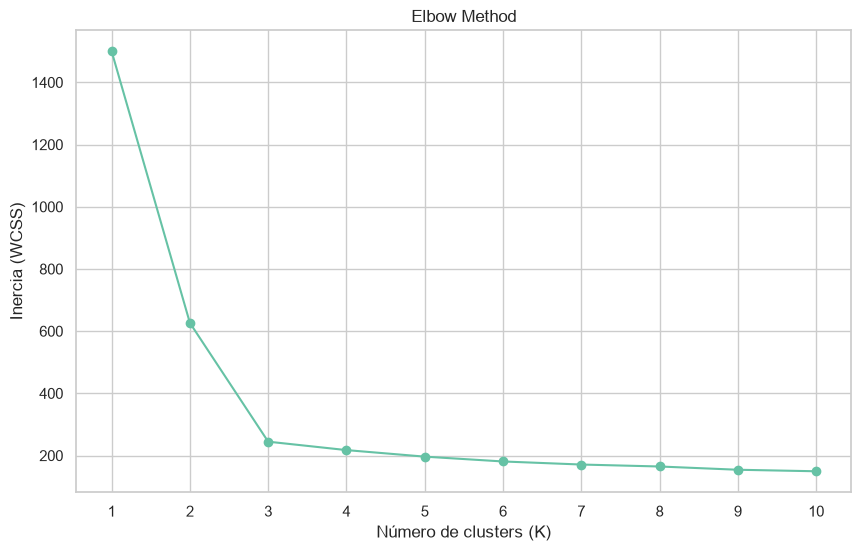

In [9]:
k_range_elbow = range(1, 11)
X_modelo = X_scaled.drop('cluster', axis=1)

inercias = []
for k in k_range_elbow:
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo_k.fit(X_modelo)
    inercias.append(modelo_k.inertia_)

plt.plot(list(k_range_elbow), inercias, 'o-')
plt.title('Elbow Method')
plt.xlabel('Número de clusters (K)'); plt.ylabel('Inercia (WCSS)')
plt.xticks(list(k_range_elbow))
plt.show()

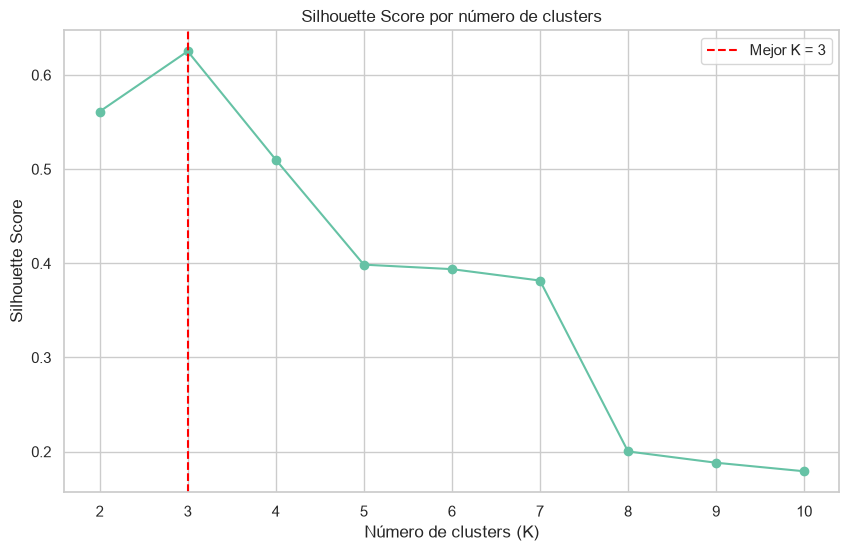

Mejor score: 0.625 para K = 3


In [10]:
k_range_silhouette = range(2, 11)

silhouette_scores = []
for k in k_range_silhouette:
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = modelo_k.fit_predict(X_modelo)
    silhouette_scores.append(silhouette_score(X_modelo, labels_k))

mejor_i = int(np.argmax(silhouette_scores))
mejor_k = list(k_range_silhouette)[mejor_i]
mejor_score = silhouette_scores[mejor_i]

plt.plot(list(k_range_silhouette), silhouette_scores, 'o-')
plt.axvline(mejor_k, color='red', linestyle='--', label=f'Mejor K = {mejor_k}')
plt.title('Silhouette Score por número de clusters')
plt.xlabel('Número de clusters (K)'); plt.ylabel('Silhouette Score')
plt.xticks(list(k_range_silhouette)); plt.legend(); plt.show()
print(f'Mejor score: {mejor_score:.3f} para K = {mejor_k}')

**Lectura de los dos gráficos:** la inercia cae fuerte de K=2 a K=3 (de ~626 a ~244) y a partir de ahí la mejora por cada K adicional es mucho menor — ese es el codo. El Silhouette Score confirma lo mismo por otro camino: el valor más alto (0.625) aparece justo en K=3. Ambos métodos coinciden, y además coincide con el K=3 que usamos "a ojo" en la Parte 4 — tiene sentido, porque el dataset se generó a propósito con 3 grupos.

Cuando los dos métodos no coinciden (algo muy común en datos reales), conviene priorizar el Silhouette Score por ser más objetivo, pero siempre chequeando que el K elegido tenga sentido interpretativo para el problema.


---
## Clasificando un cliente nuevo (y un bug típico a tener en cuenta)

Una vez entrenado el modelo, podemos preguntarle a qué cluster pertenecería un cliente que no vimos antes. El punto clave: **hay que aplicarle el mismo `scaler` ya ajustado** (con `.transform()`, *nunca* `.fit_transform()` de nuevo) — si reentrenáramos el scaler con el cliente nuevo incluido, estaríamos "filtrando" información nueva hacia atrás (esto se llama *data leakage*) y further, un solo cliente no alcanza para calcular una media/desvío confiables.

En el TP original esta celda traía un **bug**: el nuevo cliente se armaba con columnas (`gasto_anual`, `antiguedad`) que no coincidían con los nombres usados al entrenar (`gasto_mensual`, `antiguedad_meses`), y con `ingreso_anual: 65000` en una escala 1000 veces mayor a la del dataset de entrenamiento (que está en "miles de $", o sea ~20 a 95, no 65000). Como `scaler.transform()` espera exactamente las mismas columnas —incluso el mismo orden— con las que se entrenó, esto rompía la predicción. La versión corregida:


In [11]:
nuevo_cliente = pd.DataFrame([{
    'edad': 35,
    'ingreso_anual': 65,
    'gasto_mensual': 180,
    'frecuencia_compras': 12,
    'antiguedad_meses': 4
}])

nuevo_cliente_scaled = scaler.transform(nuevo_cliente)
cluster_nuevo = kmeans.predict(nuevo_cliente_scaled)
print('El nuevo cliente pertenece al cluster:', cluster_nuevo[0])

distancias = kmeans.transform(nuevo_cliente_scaled)
print('Distancia a cada centroide:', distancias)

El nuevo cliente pertenece al cluster: 2
Distancia a cada centroide: [[3.20228764 2.85815388 1.8330372 ]]


C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
C:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


`kmeans.transform(...)` devuelve la distancia del punto a **cada uno** de los K centroides (no solo al asignado) — sirve para ver qué tan "seguro" está el modelo de la asignación: si la distancia al cluster ganador es mucho menor que a los demás, la asignación es clara; si son todas parecidas, el punto está en una zona ambigua entre clusters (algo parecido a lo que vimos con `predict_proba` en los Bosques Aleatorios, aunque acá no es una probabilidad sino una distancia).

---
## Parte 6 — PCA: visualizar clusters de más de 2 dimensiones

### El problema

Tenemos 5 variables (`edad`, `ingreso_anual`, `gasto_mensual`, `frecuencia_compras`, `antiguedad_meses`). No podemos graficar un espacio de 5 dimensiones para *ver* si los clusters están bien separados.

### La solución: PCA (Análisis de Componentes Principales)

PCA busca nuevas variables — llamadas **componentes principales** (PC1, PC2, ...) — que son **combinaciones lineales** de las variables originales, elegidas para capturar la mayor cantidad posible de varianza (información) de los datos. Tomando solo las dos primeras (PC1 y PC2), podemos proyectar todo el dataset en un plano 2D y graficarlo, aunque originalmente tuviera muchas más dimensiones.

**Importante:** PCA se aplica siempre sobre los datos **escalados**, y solo se usa para *visualizar* — el modelo K-Means ya fue entrenado con las 5 variables originales escaladas; PCA no cambia ni reentrena el clustering, solo lo dibuja de otra forma.


In [12]:
X_sin_cluster = X_scaled.drop('cluster', axis=1)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sin_cluster)

varianza_explicada = pca.explained_variance_ratio_
print(f'Varianza explicada por PC1: {varianza_explicada[0]:.2%}')
print(f'Varianza explicada por PC2: {varianza_explicada[1]:.2%}')
print(f'Varianza total explicada: {sum(varianza_explicada):.2%}')

Varianza explicada por PC1: 62.46%
Varianza explicada por PC2: 27.32%
Varianza total explicada: 89.78%


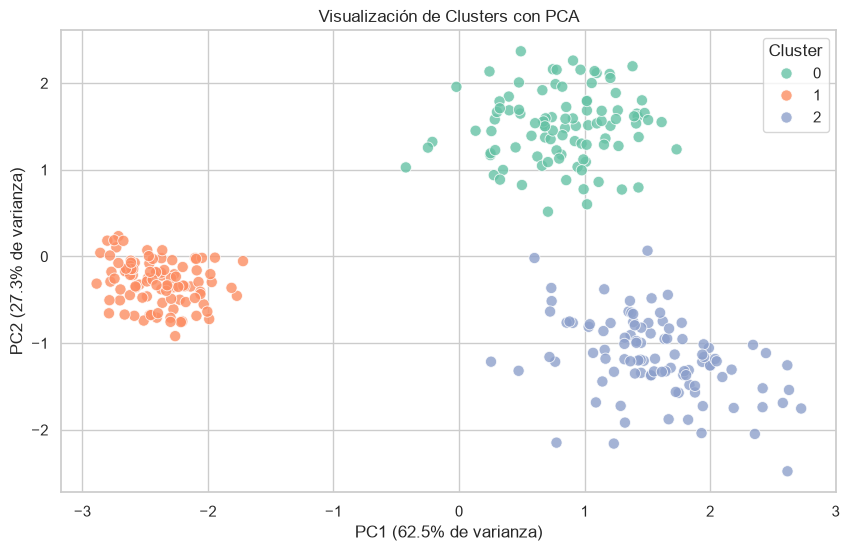

In [13]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = df['cluster'].to_numpy()

sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster',
                palette='Set2', s=65, alpha=0.8)
plt.title('Visualización de Clusters con PCA')
plt.xlabel(f'PC1 ({varianza_explicada[0]:.1%} de varianza)')
plt.ylabel(f'PC2 ({varianza_explicada[1]:.1%} de varianza)')
plt.legend(title='Cluster'); plt.show()

Con solo 2 de las 5 dimensiones originales, capturamos ~90% de la varianza total — muy poca pérdida de información — y en el gráfico se ven 3 nubes de puntos bastante separadas, que confirman visualmente lo que ya sabíamos por el Silhouette Score: los clusters están bien definidos.

### Loadings: qué significan PC1 y PC2

Los **loadings** son los coeficientes de la combinación lineal — cuánto "pesa" cada variable original dentro de cada componente principal.

                      PC1    PC2
edad                0.392  0.566
ingreso_anual       0.517 -0.150
gasto_mensual       0.484 -0.329
frecuencia_compras  0.430 -0.485
antiguedad_meses    0.399  0.560


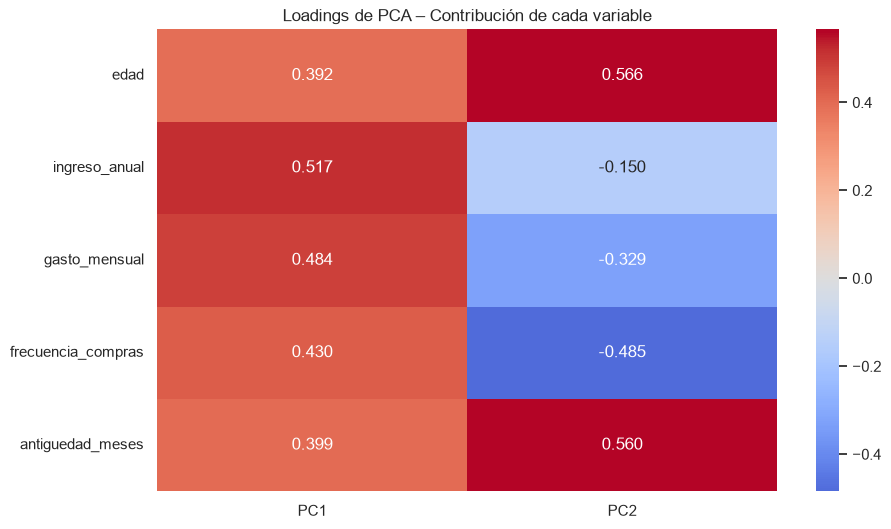

In [14]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=X_sin_cluster.columns)
print(loadings.round(3))

sns.heatmap(loadings, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Loadings de PCA – Contribución de cada variable')
plt.show()

**Cómo leer esta tabla:**
- **PC1** tiene cargas positivas y parejas en las 5 variables (`ingreso_anual` 0.52, `gasto_mensual` 0.48, `frecuencia_compras` 0.43, `antiguedad_meses` 0.40, `edad` 0.39). Funciona como un eje general de "magnitud del cliente": a mayor PC1, más alto todo en conjunto.
- **PC2** contrapone `edad` y `antiguedad_meses` (cargas positivas, ~0.57 y ~0.56) contra `gasto_mensual` y `frecuencia_compras` (cargas negativas, -0.33 y -0.49). Es el eje que separa a los clientes "grandes en edad/antigüedad" de los "grandes en gasto/frecuencia" — coherente con que el cluster 0 (maduros) y el cluster 2 (premium) queden en lados opuestos del gráfico de dispersión.

No hace falta memorizar esta lectura — lo importante es el método: mirar qué variables tienen las cargas más grandes (en valor absoluto) en cada componente, y si van todas en el mismo signo o se contraponen.


---
## Parte 7 — Ejercicio integrador: aplicando todo el pipeline solo

La Parte 7 del TP no da ningún resultado previo — hay que aplicar, sin ayuda, el pipeline completo (explorar → escalar → elegir K → entrenar → PCA → interpretar → detectar anomalías) sobre un dataset nuevo: usuarios de una plataforma de streaming, con 6 variables de comportamiento (`horas_por_semana`, `generos_distintos`, `dias_activo_mes`, `peliculas_completadas`, `series_completadas`, `busquedas_semana`).

La resolución sigue exactamente los mismos pasos de las Partes 2 a 6, aplicados a `df_streaming` en vez de `df`. Lo único nuevo es el **Paso 7: detección de anomalías**, que no se había usado en el ejemplo de clientes.

### ¿Cómo detectar anomalías con K-Means?

K-Means tiene una limitación importante (mencionada en las diapositivas): hace **asignación forzada** — todo punto termina asignado a algún cluster, incluso si es un caso atípico que no se parece bien a ninguno. Para detectar esos casos "raros", usamos `kmeans.transform()` (la misma función que usamos para el cliente nuevo) para medir la distancia de cada punto a **su propio centroide asignado**. Los puntos con una distancia inusualmente grande (definimos el umbral como *media + 2 desvíos estándar* de esa distancia) son candidatos a "atípicos": están en su cluster porque tenían que ir a alguno, pero no se parecen mucho a sus compañeros de grupo.


In [15]:
rng = np.random.default_rng(42)

def generar_perfil(n, horas, generos, dias, peliculas, series, busquedas):
    intensidad = rng.normal(0, 1, n)
    return pd.DataFrame({
        'horas_por_semana': rng.normal(horas, 1.8, n) + 0.6 * intensidad,
        'generos_distintos': rng.normal(generos, 0.8, n) + 0.1 * intensidad,
        'dias_activo_mes': rng.normal(dias, 2.5, n) + 0.6 * intensidad,
        'peliculas_completadas': rng.normal(peliculas, 1.6, n) + 0.3 * intensidad,
        'series_completadas': rng.normal(series, 1.5, n) + 0.3 * intensidad,
        'busquedas_semana': rng.normal(busquedas, 1.7, n) + 0.2 * intensidad
    })

usuarios_ocasionales = generar_perfil(140, 4, 3, 7, 2, 1, 3)
usuarios_peliculas = generar_perfil(130, 11, 6, 16, 9, 3, 8)
usuarios_series = generar_perfil(130, 16, 4, 22, 3, 9, 5)

df_streaming = pd.concat([usuarios_ocasionales, usuarios_peliculas, usuarios_series], ignore_index=True)

df_streaming['horas_por_semana'] = df_streaming['horas_por_semana'].clip(0, 35).round(2)
df_streaming['generos_distintos'] = df_streaming['generos_distintos'].clip(1, 12).round().astype(int)
df_streaming['dias_activo_mes'] = df_streaming['dias_activo_mes'].clip(1, 30).round().astype(int)
df_streaming['peliculas_completadas'] = df_streaming['peliculas_completadas'].clip(0, 20).round().astype(int)
df_streaming['series_completadas'] = df_streaming['series_completadas'].clip(0, 20).round().astype(int)
df_streaming['busquedas_semana'] = df_streaming['busquedas_semana'].clip(0, 20).round(2)

df_streaming = df_streaming.sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Shape: {df_streaming.shape}')
df_streaming.head()

Shape: (400, 6)


,horas_por_semana,generos_distintos,dias_activo_mes,peliculas_completadas,series_completadas,busquedas_semana
0,12.01,6,19,7,3,7.70
1,18.02,4,23,0,6,6.98
2,1.31,3,12,0,0,2.94
3,7.88,5,14,9,1,9.02
4,6.12,4,7,0,2,5.78


                       count   mean   std  min   25%    50%    75%    max
horas_por_semana       400.0  10.09  5.30  0.0  4.87  10.66  14.69  21.82
generos_distintos      400.0   4.28  1.55  1.0  3.00   4.00   6.00   8.00
dias_activo_mes        400.0  14.82  6.85  1.0  8.00  16.00  21.00  28.00
peliculas_completadas  400.0   4.54  3.44  0.0  2.00   4.00   8.00  14.00
series_completadas     400.0   4.26  3.61  0.0  1.00   3.00   8.00  13.00
busquedas_semana       400.0   5.22  2.60  0.0  3.29   5.03   7.21  12.68

Valores nulos:
horas_por_semana         0
generos_distintos        0
dias_activo_mes          0
peliculas_completadas    0
series_completadas       0
busquedas_semana         0
dtype: int64


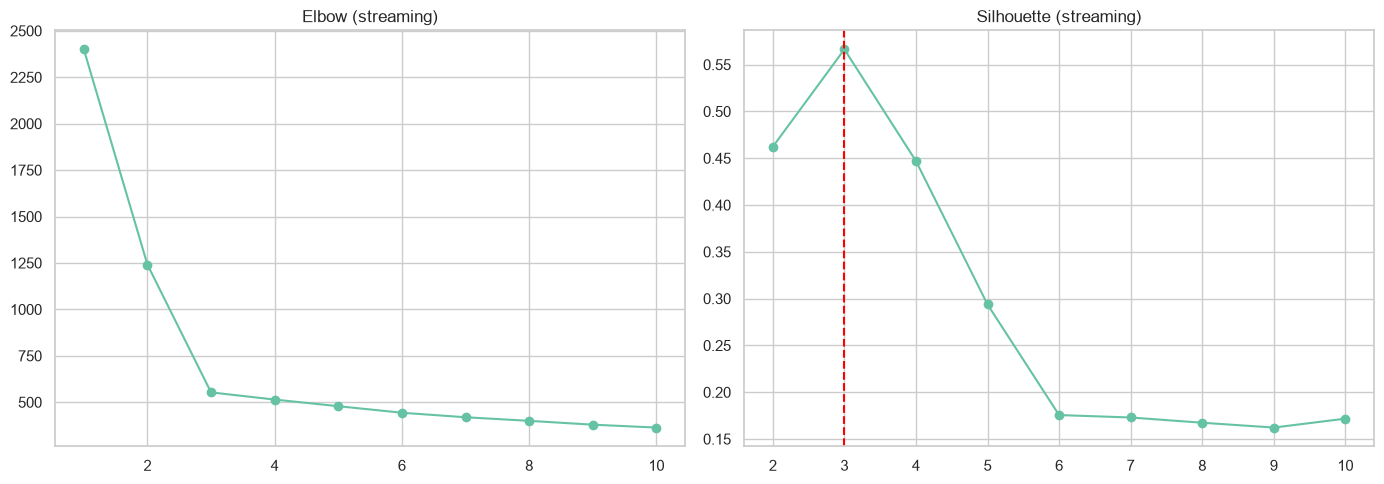

Mejor K por Silhouette: 3 (score=0.566)
Tamaño de cada cluster:
cluster
0    130
1    140
2    130
Name: count, dtype: int64


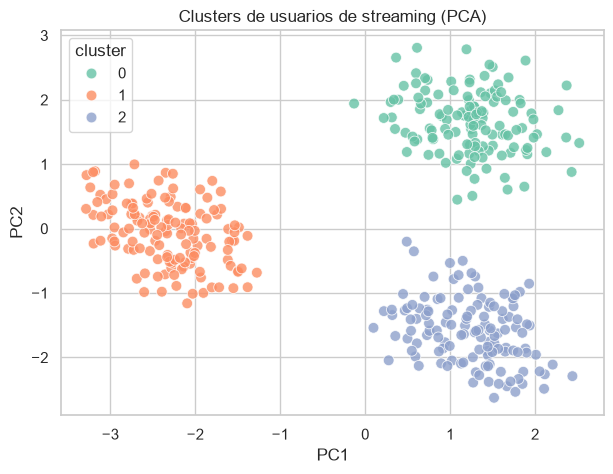

         horas_por_semana  generos_distintos  dias_activo_mes  \
cluster                                                         
0                   15.92               3.86            22.11   
1                    3.94               3.01             6.88   
2                   10.89               6.05            16.10   

         peliculas_completadas  series_completadas  busquedas_semana  
cluster                                                               
0                         3.05                8.96              5.03  
1                         1.94                1.24              2.98  
2                         8.83                2.80              7.83  

Umbral de anomalía: 1.80  |  Usuarios atípicos: 8 de 400


In [16]:
# Paso 1: Exploración
print(df_streaming.describe().T.round(2))
print('\nValores nulos:'); print(df_streaming.isnull().sum())

# Paso 2: Escalado
scaler_streaming = StandardScaler()
X_streaming_scaled = pd.DataFrame(
    scaler_streaming.fit_transform(df_streaming),
    columns=df_streaming.columns, index=df_streaming.index
)

# Paso 3: K óptimo
k_range_elbow_s = range(1, 11)
inercias_s = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_streaming_scaled).inertia_
              for k in k_range_elbow_s]

k_range_sil_s = range(2, 11)
sil_s = [silhouette_score(X_streaming_scaled,
         KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_streaming_scaled))
         for k in k_range_sil_s]

mejor_k_s = list(k_range_sil_s)[int(np.argmax(sil_s))]
mejor_score_s = max(sil_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range_elbow_s), inercias_s, 'o-'); axes[0].set_title('Elbow (streaming)')
axes[1].plot(list(k_range_sil_s), sil_s, 'o-'); axes[1].axvline(mejor_k_s, color='red', linestyle='--')
axes[1].set_title('Silhouette (streaming)')
plt.tight_layout(); plt.show()
print(f'Mejor K por Silhouette: {mejor_k_s} (score={mejor_score_s:.3f})')

# Paso 4: modelo final
kmeans_streaming = KMeans(n_clusters=mejor_k_s, random_state=42, n_init=10, init='k-means++')
kmeans_streaming.fit(X_streaming_scaled)
df_streaming['cluster'] = kmeans_streaming.labels_
X_streaming_scaled['cluster'] = kmeans_streaming.labels_
print('Tamaño de cada cluster:'); print(df_streaming['cluster'].value_counts().sort_index())

# Paso 5: PCA
X_streaming_sin_cluster = X_streaming_scaled.drop('cluster', axis=1)
pca_streaming = PCA(n_components=2, random_state=42)
X_streaming_pca = pca_streaming.fit_transform(X_streaming_sin_cluster)
df_streaming_pca = pd.DataFrame(X_streaming_pca, columns=['PC1', 'PC2'])
df_streaming_pca['cluster'] = df_streaming['cluster'].to_numpy()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_streaming_pca, x='PC1', y='PC2', hue='cluster', palette='Set2', s=60, alpha=0.8)
plt.title('Clusters de usuarios de streaming (PCA)'); plt.show()

# Paso 6: interpretación
perfil_streaming = df_streaming.groupby('cluster').mean().round(2)
print(perfil_streaming)

# Paso 7: anomalías
distancias_todas = kmeans_streaming.transform(X_streaming_sin_cluster)
distancia_asignada = distancias_todas[np.arange(len(df_streaming)), kmeans_streaming.labels_]
umbral = distancia_asignada.mean() + 2 * distancia_asignada.std()
n_anomalos = (distancia_asignada > umbral).sum()
print(f'\nUmbral de anomalía: {umbral:.2f}  |  Usuarios atípicos: {n_anomalos} de {len(df_streaming)}')

**Resultado:** tanto el Elbow como el Silhouette Score (0.566) coinciden en **K=3**, y los tres clusters que aparecen coinciden en tamaño con los tres perfiles usados para simular los datos (140 ocasionales, 130 orientados a películas, 130 orientados a series) — de nuevo, K-Means reconstruyó solo, a partir del comportamiento, una estructura que nosotros ya conocíamos de antemano. El Silhouette (0.566) da un poco más bajo que en el ejemplo de clientes (0.625): tiene sentido, porque acá los datos se generaron con un factor de "intensidad" compartido entre variables que hace que los grupos se solapen un poco más — más parecido a lo ruidoso que suele ser un dataset real.

Con la distancia al centroide detectamos ~8 usuarios atípicos (~2% del total): personas cuyo comportamiento es una mezcla de perfiles y no encaja bien en ninguno. Son candidatos a revisar manualmente antes de incluirlos en una campaña masiva dirigida a "su" cluster.


---
## Limitaciones de K-Means (para tener en cuenta siempre)

No es un algoritmo mágico — conviene conocer sus supuestos antes de confiar ciegamente en sus resultados:

- **Sensible a la escala** de las variables (por eso el escalado es obligatorio, no opcional).
- Los **outliers** pueden desplazar los centroides — un solo punto muy extremo puede arrastrar el centro de todo un cluster.
- **No trabaja naturalmente con variables categóricas** (solo con numéricas, porque calcula distancias y promedios).
- Hay que **definir K de antemano** — el algoritmo no "descubre" cuántos clusters hay, hay que decírselo (con ayuda del Elbow/Silhouette).
- Funciona mejor con clusters **compactos y de forma redondeada** — si los grupos reales tienen formas alargadas o irregulares, K-Means los va a partir mal (ahí convendría un algoritmo como DBSCAN).
- El resultado puede variar según la inicialización de los centroides (por eso usamos `n_init=10` y `random_state` fijo).
- **Asignación forzada**: todo punto termina en algún cluster, incluso si es un caso atípico — de ahí la utilidad de la detección de anomalías de la Parte 7.
- Los clusters que encuentra son una forma matemática de organizar los datos, **no necesariamente tienen un significado de negocio real** — siempre hay que interpretarlos con criterio humano antes de actuar sobre ellos.


---
## Cheat-sheet: el flujo completo, de memoria

```
1. Explorar   → df.describe() + isnull().sum()  → entender rangos y escalas
2. Escalar    → StandardScaler().fit_transform(df) → SIEMPRE antes de K-Means
3. Elegir K   → Elbow (inercia) + Silhouette Score  → mirar dónde se aplana / dónde es máximo
4. Entrenar   → KMeans(n_clusters=K, random_state=.., n_init=10).fit(X_scaled)
5. Interpretar→ df.groupby('cluster').mean()  → perfil promedio de cada grupo
6. Visualizar → PCA(n_components=2) sobre X_scaled  → proyección 2D + loadings
7. Anomalías  → kmeans.transform()  → distancia al propio centroide, puntos "raros"
```

| Pregunta | Herramienta |
|---|---|
| ¿Los datos están en escalas comparables? | `describe()` + boxplot antes/después de `StandardScaler` |
| ¿Cuántos grupos elegir? | Elbow Method + Silhouette Score (idealmente ambos coincidiendo) |
| ¿Qué representa cada grupo? | `groupby('cluster').mean()` + heatmap de perfil |
| ¿Los grupos están bien separados? | Silhouette Score global + scatter de PCA |
| ¿Qué variables originales explican cada eje del gráfico? | `pca.components_` (loadings) |
| ¿Hay puntos raros que no encajan bien? | Distancia de cada punto a su centroide asignado |
